# Lab 3 - 3 - Imputation for Time Series Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a date range
date_range = pd.date_range(start='2023-01-01', end='2023-12-31', freq='W')
num_rows = len(date_range)

# 2. Generate Seasonal Data using a Sine Wave
np.random.seed(41)
# Create an array from 0 to 2*pi over the length of the dataset
x = np.linspace(0, 4 * np.pi, num_rows)

# Define the trend: Base Sales + (Amplitude * sin(x)) + Random Noise
base_sales = 13500
amplitude = 1500
seasonal_trend = base_sales + amplitude * np.sin(x)
noise = np.random.normal(0, 200, size=num_rows) # Adding slight variance

sales_data = (seasonal_trend + noise).round(2)

# 3. Setting missing data
num_sales_missing = 9
missing_sales_indices = np.random.choice(num_rows, size=min(num_sales_missing, num_rows), replace=False)
sales_data[missing_sales_indices] = np.nan

# 4. Create the DataFrame
time_series_df = pd.DataFrame({
    'Date': date_range,
    'Sales': sales_data
})

# 5. Set the Date column as the index
time_series_df.set_index('Date', inplace=True)

print(time_series_df.head(10))

               Sales
Date                
2023-01-01  13445.86
2023-01-08  13879.94
2023-01-15       NaN
2023-01-22  14309.64
2023-01-29       NaN
2023-02-05       NaN
2023-02-12  14958.33
2023-02-19  15147.03
2023-02-26  14657.28
2023-03-05  14544.87


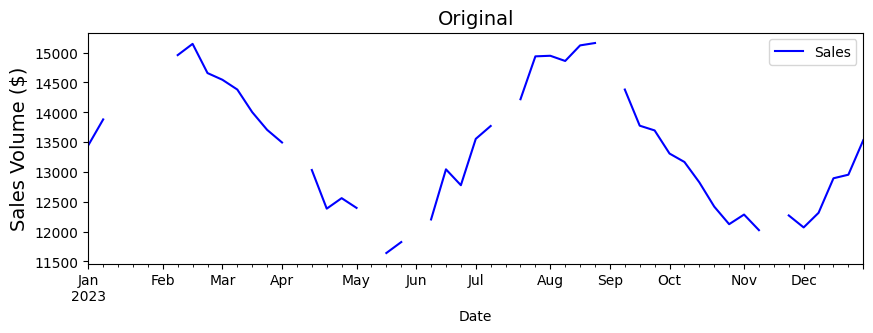

In [2]:
# Plot of the data with missing values
plt.figure(figsize=(10, 3))
time_series_df['Sales'].plot(color='blue')
plt.title('Original', fontsize=14)
plt.ylabel('Sales Volume ($)', fontsize=14)
plt.legend()
plt.show()

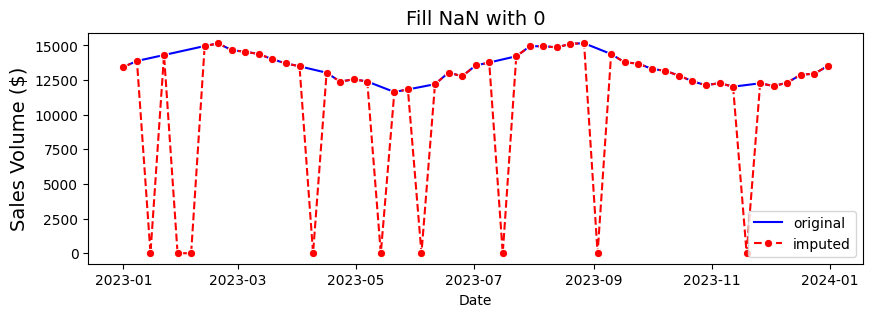

In [ ]:
# Impute missing data with 0
# Plot the original data with missing values with blue line color.
# Plot the imputed data with red line color.
imputed = time_series_df.copy()
imputed['Sales'] = imputed['Sales'].fillna(0)

plt.figure(figsize=(10, 3))
sns.lineplot(x=imputed.index, y=time_series_df['Sales'], color='blue', label='original')
sns.lineplot(x=imputed.index, y=imputed['Sales'], color='red', label='imputed', linestyle='--', marker='o')
plt.title('Fill NaN with 0', fontsize=14)
plt.ylabel('Sales Volume ($)', fontsize=14)
plt.legend()
plt.show()

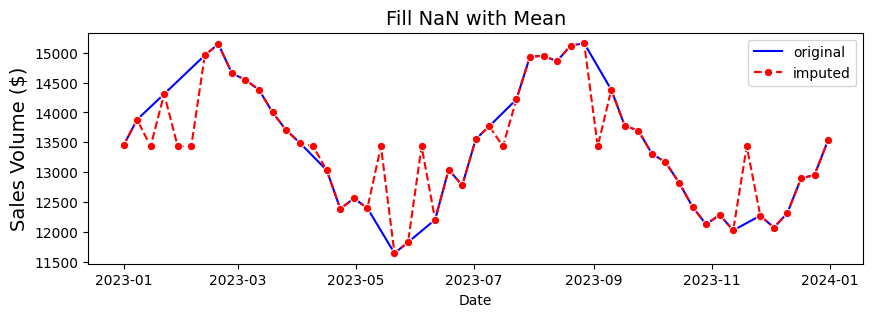

In [ ]:
# Impute missing data average
# Plot the original data with missing values with blue line color.
# Plot the imputed data with red line color.

imputed = time_series_df.copy()
avg_sales = time_series_df['Sales'].mean()
imputed['Sales'] = imputed['Sales'].fillna(avg_sales)

plt.figure(figsize=(10, 3))
sns.lineplot(x=imputed.index, y=time_series_df['Sales'], color='blue', label='original')
sns.lineplot(x=imputed.index, y=imputed['Sales'], color='red', label='imputed', linestyle='--', marker='o')
plt.title('Fill NaN with Mean', fontsize=14)
plt.ylabel('Sales Volume ($)', fontsize=14)
plt.legend()
plt.show()

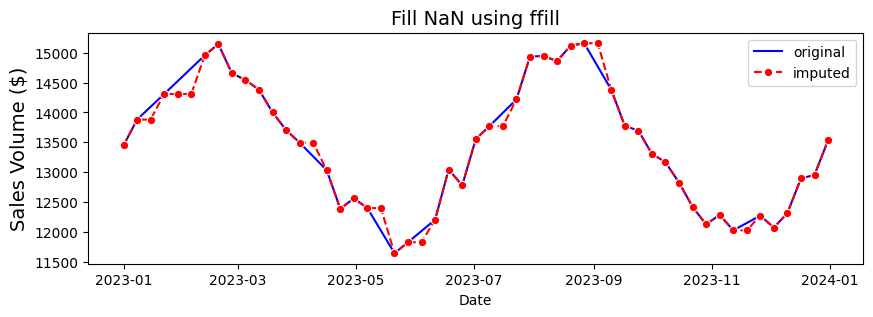

In [ ]:
# Impute missing data using ffill
# Plot the original data with missing values with blue line color.
# Plot the imputed data with red line color.

imputed = time_series_df.copy()
imputed['Sales'] = imputed['Sales'].ffill()

plt.figure(figsize=(10, 3))
sns.lineplot(x=imputed.index, y=time_series_df['Sales'], color='blue', label='original')
sns.lineplot(x=imputed.index, y=imputed['Sales'], color='red', label='imputed', linestyle='--', marker='o')
plt.title('Fill NaN using ffill', fontsize=14)
plt.ylabel('Sales Volume ($)', fontsize=14)
plt.legend()
plt.show()

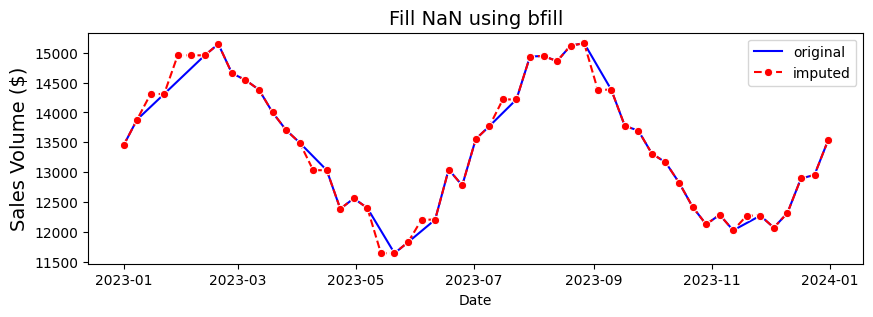

In [ ]:
# Impute missing data using bfill
# Plot the original data with missing values with blue line color.
# Plot the imputed data with red line color.

imputed = time_series_df.copy()
imputed['Sales'] = imputed['Sales'].bfill()

plt.figure(figsize=(10, 3))
sns.lineplot(x=imputed.index, y=time_series_df['Sales'], color='blue', label='original')
sns.lineplot(x=imputed.index, y=imputed['Sales'], color='red', label='imputed', linestyle='--', marker='o')
plt.title('Fill NaN using bfill', fontsize=14)
plt.ylabel('Sales Volume ($)', fontsize=14)
plt.legend()
plt.show()